### Import Packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import chi2
from scipy import stats
from scipy.stats import f_oneway
sns.set_theme(style='whitegrid')

### Loading Structured Data from CSV

In [ ]:
df = pd.read_csv('2014_Financial_Data_Selected.csv', index_col=0)
print(f"Data type: Structured (tabular)")
print(f"Source: Financial database CSV\n")
df

Data type: Structured (tabular)
Source: Financial database CSV



,Sector,2015 PRICE VAR [%],Class,Revenue,Revenue Growth,Gross Margin,Operating Income,Net Income,Net Profit Margin,returnOnEquity,returnOnAssets,PE ratio,Price to Sales Ratio,EV to Sales,Debt to Equity,Current ratio,Operating Cash Flow,Free Cash Flow,EPS Diluted Growth,Net Income Growth
PG,Consumer Defensive,-9.323276,0,7.440100e+10,-0.0713,0.475400,1.391000e+10,1.164300e+10,0.156500,0.1664,0.5765,18.7566,2.8583,3.1907,0.5061,0.9370,1.395800e+10,1.011000e+10,0.0389,0.0293
VIPS,Consumer Defensive,-25.512193,0,3.734148e+09,1.1737,0.248700,1.345959e+08,1.358227e+08,0.036400,0.3294,0.0403,81.5526,0.0443,NaN,1.5093,0.2102,5.267456e+08,2.630410e+08,1.4646,1.5649
KR,Consumer Defensive,33.118297,1,9.837500e+10,0.0182,0.205700,2.725000e+09,1.519000e+09,0.015400,0.2821,0.1011,12.0340,0.1858,0.2967,2.1007,0.8250,3.573000e+09,1.243000e+09,0.0469,0.0147
RAD,Consumer Defensive,2.752291,1,2.552641e+10,0.0053,0.286900,7.372520e+08,2.494140e+08,0.009800,-0.1180,0.0668,28.6087,0.2491,0.4689,-2.7237,1.7090,7.020460e+08,3.681760e+08,0.9167,1.0043
GIS,Consumer Defensive,12.897715,1,1.790960e+10,0.0076,0.355700,2.957400e+09,1.824400e+09,0.101900,0.2792,0.6265,18.7034,1.8610,2.3032,1.3445,0.8100,2.541000e+09,1.884100e+09,0.0143,-0.0166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSRI,Technology,29.362884,1,4.952987e+07,0.1028,0.167100,2.516800e+04,-8.593600e+04,-0.001700,-0.0097,-0.0098,0.0000,0.1216,0.0337,0.0000,2.8750,5.239870e+05,4.909530e+05,0.8462,0.8348
TZOO,Technology,-31.167763,0,1.532400e+08,-0.1019,0.874900,1.781000e+07,1.306200e+07,0.085200,0.3646,0.2855,14.3409,1.2131,0.8390,0.0279,1.8410,-1.587000e+06,-5.400000e+06,3.0465,2.9845
USATP,Technology,-23.558900,0,4.200000e+07,NaN,0.357143,0.000000e+00,2.800000e+07,0.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.000000e+06,-4.000000e+06,NaN,NaN
WSTG,Technology,7.779579,1,3.407580e+08,0.1344,0.072800,8.297000e+06,5.760000e+06,0.016900,0.1456,0.1824,13.8790,0.2476,0.1797,0.0000,1.5620,5.745000e+06,5.434000e+06,-0.1277,-0.0990


In [ ]:
df.isnull().sum()

,0
Sector,0
2015 PRICE VAR [%],0
Class,0
Revenue,44
Revenue Growth,236
Gross Margin,47
Operating Income,55
Net Income,23
Net Profit Margin,57
returnOnEquity,192


**Interpretation:** 3808 stocks, 20 features covering profitability, valuation, leverage, growth, and a binary class label (1 = stock beat market in 2015).

In [ ]:
# Column overview
print("\nData types:")
print(df.dtypes)


Data types:
Sector                   object
2015 PRICE VAR [%]      float64
Class                     int64
Revenue                 float64
Revenue Growth          float64
Gross Margin            float64
Operating Income        float64
Net Income              float64
Net Profit Margin       float64
returnOnEquity          float64
returnOnAssets          float64
PE ratio                float64
Price to Sales Ratio    float64
EV to Sales             float64
Debt to Equity          float64
Current ratio           float64
Operating Cash Flow     float64
Free Cash Flow          float64
EPS Diluted Growth      float64
Net Income Growth       float64
dtype: object


### Descriptive Statistics

In [ ]:
df.describe()

,2015 PRICE VAR [%],Class,Revenue,Revenue Growth,Gross Margin,Operating Income,Net Income,Net Profit Margin,returnOnEquity,returnOnAssets,PE ratio,Price to Sales Ratio,EV to Sales,Debt to Equity,Current ratio,Operating Cash Flow,Free Cash Flow,EPS Diluted Growth,Net Income Growth
count,3.808000e+03,3808.000000,3.764000e+03,3572.000000,3761.000000,3.753000e+03,3.785000e+03,3751.000000,3.616000e+03,2813.000000,3654.000000,3654.000000,3154.000000,3623.000000,2820.000000,3.768000e+03,3.761000e+03,3515.000000,3565.000000
mean,9.751560e+02,0.429097,5.879050e+09,12.954244,0.469036,6.748248e+08,4.894335e+08,-3.784724,1.941046e+03,0.073683,29.168906,44.972676,42.642911,1.247731,6.872239,1.191508e+09,4.453619e+08,0.140394,-0.426786
std,4.098461e+04,0.495012,3.901741e+10,705.605473,1.061432,3.786291e+09,4.396692e+09,63.300580,1.167203e+05,9.590453,169.445219,632.513736,628.930733,36.500177,123.059397,1.683247e+10,4.060265e+09,5.934814,29.049961
min,-1.003972e+02,0.000000,-6.276160e+08,-1.773200,-53.176500,-6.786000e+09,-8.360000e+09,-3053.200000,-7.101360e+01,-278.863200,0.000000,0.000000,-271.564000,-263.458300,-1.439300,-3.175545e+10,-1.042394e+11,-85.007900,-1110.006500
25%,-2.857143e+01,0.000000,5.788880e+07,-0.002350,0.248700,-1.308000e+06,-3.693000e+06,-0.001700,-2.085000e-02,-0.099300,0.000000,0.807675,0.963650,0.004700,1.223500,1.281011e+06,-1.141200e+07,-0.287900,-0.377500
50%,-5.281842e+00,0.000000,4.349010e+08,0.061850,0.449900,4.104400e+07,2.223100e+07,0.051200,7.795000e-02,0.055800,14.682450,1.879550,2.277600,0.389300,2.008500,5.287800e+07,1.226500e+07,0.097800,0.059100
75%,1.331484e+01,1.000000,2.393625e+09,0.188875,0.782500,2.712980e+08,1.658440e+08,0.140350,1.531500e-01,0.169700,23.996825,4.195425,5.710050,1.019850,3.476250,3.145500e+08,1.429070e+08,0.528400,0.452900
max,2.418601e+06,1.000000,1.824698e+12,42138.663900,2.659900,1.565540e+11,2.339970e+11,97.396100,7.018763e+06,345.631000,4972.650400,26397.558500,23710.175200,2131.512800,5852.228000,9.600000e+11,9.887000e+10,134.000000,475.714300


### Indexing & Subsetting

In [ ]:
# Column subset - profitability features
profitability_cols = ['Gross Margin', 'Net Profit Margin', 'returnOnEquity', 'returnOnAssets']
df[profitability_cols].head()

,Gross Margin,Net Profit Margin,returnOnEquity,returnOnAssets
PG,0.4754,0.1565,0.1664,0.5765
VIPS,0.2487,0.0364,0.3294,0.0403
KR,0.2057,0.0154,0.2821,0.1011
RAD,0.2869,0.0098,-0.1180,0.0668
GIS,0.3557,0.1019,0.2792,0.6265


In [ ]:
# Label-based encoding
df.loc['PG']

,PG
Sector,Consumer Defensive
2015 PRICE VAR [%],-9.323276
Class,0
Revenue,74401000000.0
Revenue Growth,-0.0713
Gross Margin,0.4754
Operating Income,13910000000.0
Net Income,11643000000.0
Net Profit Margin,0.1565
returnOnEquity,0.1664


### Renaming Columns

In [ ]:
df.rename(columns={
    '2015 PRICE VAR [%]': 'price_change_pct',
    'PE ratio': 'pe_ratio',
    'Price to Sales Ratio': 'ps_ratio',
    'EV to Sales': 'ev_to_sales',
    'Debt to Equity': 'debt_to_equity',
    'Current ratio': 'current_ratio',
    'Revenue Growth': 'revenue_growth',
    'Gross Margin': 'gross_margin',
    'Operating Income': 'operating_income',
    'Net Income': 'net_income',
    'Net Profit Margin': 'net_profit_margin',
    'Operating Cash Flow': 'op_cash_flow',
    'Free Cash Flow': 'free_cash_flow',
    'EPS Diluted Growth': 'eps_growth',
    'Net Income Growth': 'ni_growth',
    'returnOnEquity': 'roe',
    'returnOnAssets': 'roa'
}, inplace=True)

df

,Sector,price_change_pct,Class,Revenue,revenue_growth,gross_margin,operating_income,net_income,net_profit_margin,roe,roa,pe_ratio,ps_ratio,ev_to_sales,debt_to_equity,current_ratio,op_cash_flow,free_cash_flow,eps_growth,ni_growth
PG,Consumer Defensive,-9.323276,0,7.440100e+10,-0.0713,0.475400,1.391000e+10,1.164300e+10,0.156500,0.1664,0.5765,18.7566,2.8583,3.1907,0.5061,0.9370,1.395800e+10,1.011000e+10,0.0389,0.0293
VIPS,Consumer Defensive,-25.512193,0,3.734148e+09,1.1737,0.248700,1.345959e+08,1.358227e+08,0.036400,0.3294,0.0403,81.5526,0.0443,NaN,1.5093,0.2102,5.267456e+08,2.630410e+08,1.4646,1.5649
KR,Consumer Defensive,33.118297,1,9.837500e+10,0.0182,0.205700,2.725000e+09,1.519000e+09,0.015400,0.2821,0.1011,12.0340,0.1858,0.2967,2.1007,0.8250,3.573000e+09,1.243000e+09,0.0469,0.0147
RAD,Consumer Defensive,2.752291,1,2.552641e+10,0.0053,0.286900,7.372520e+08,2.494140e+08,0.009800,-0.1180,0.0668,28.6087,0.2491,0.4689,-2.7237,1.7090,7.020460e+08,3.681760e+08,0.9167,1.0043
GIS,Consumer Defensive,12.897715,1,1.790960e+10,0.0076,0.355700,2.957400e+09,1.824400e+09,0.101900,0.2792,0.6265,18.7034,1.8610,2.3032,1.3445,0.8100,2.541000e+09,1.884100e+09,0.0143,-0.0166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSRI,Technology,29.362884,1,4.952987e+07,0.1028,0.167100,2.516800e+04,-8.593600e+04,-0.001700,-0.0097,-0.0098,0.0000,0.1216,0.0337,0.0000,2.8750,5.239870e+05,4.909530e+05,0.8462,0.8348
TZOO,Technology,-31.167763,0,1.532400e+08,-0.1019,0.874900,1.781000e+07,1.306200e+07,0.085200,0.3646,0.2855,14.3409,1.2131,0.8390,0.0279,1.8410,-1.587000e+06,-5.400000e+06,3.0465,2.9845
USATP,Technology,-23.558900,0,4.200000e+07,NaN,0.357143,0.000000e+00,2.800000e+07,0.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.000000e+06,-4.000000e+06,NaN,NaN
WSTG,Technology,7.779579,1,3.407580e+08,0.1344,0.072800,8.297000e+06,5.760000e+06,0.016900,0.1456,0.1824,13.8790,0.2476,0.1797,0.0000,1.5620,5.745000e+06,5.434000e+06,-0.1277,-0.0990


### Filtering & Conditional Selection


In [ ]:
# Filtering: tech sector only
tech_stocks = df[df['Sector'] == 'Technology']
tech_stocks.head()

,Sector,price_change_pct,Class,Revenue,revenue_growth,gross_margin,operating_income,net_income,net_profit_margin,roe,roa,pe_ratio,ps_ratio,ev_to_sales,debt_to_equity,current_ratio,op_cash_flow,free_cash_flow,eps_growth,ni_growth
INTC,Technology,-2.402207,0,5.587000e+10,0.0600,0.6374,1.534700e+10,1.170400e+10,0.2095,0.2095,0.2603,15.5565,3.2176,3.2104,0.2444,1.732,2.041800e+10,1.031300e+10,0.2222,0.2166
MU,Technology,-59.251799,0,1.635800e+10,0.8029,0.3324,3.087000e+09,3.045000e+09,0.1861,0.2830,0.2154,11.4321,2.1478,2.2728,0.6114,2.138,5.699000e+09,2.592000e+09,1.2478,1.5588
AAPL,Technology,-2.082268,0,1.827950e+11,0.0695,0.3859,5.250300e+10,3.951000e+10,0.2161,0.3542,1.5369,15.4253,3.2793,3.3352,0.3164,1.080,5.971300e+10,4.990000e+10,0.1356,0.0668
MSFT,Technology,21.878487,1,8.683300e+10,0.1154,0.6882,2.775900e+10,2.207400e+10,0.2542,0.2459,0.2704,15.6767,3.9669,3.2406,0.2522,2.504,3.250200e+10,2.701700e+10,0.0194,0.0097
HPQ,Technology,-32.125197,0,5.665100e+10,-0.4955,0.1981,4.256000e+09,5.013000e+09,0.0885,0.1875,0.2824,6.1257,0.5368,0.6143,0.7304,1.147,1.233300e+10,9.323000e+09,0.0000,-0.0196


In [ ]:
# Filtering: only companies with net margin > 15%
profitable = df[df['net_profit_margin'] > 0.15]
profitable.head()

,Sector,price_change_pct,Class,Revenue,revenue_growth,gross_margin,operating_income,net_income,net_profit_margin,roe,roa,pe_ratio,ps_ratio,ev_to_sales,debt_to_equity,current_ratio,op_cash_flow,free_cash_flow,eps_growth,ni_growth
PG,Consumer Defensive,-9.323276,0,7.440100e+10,-0.0713,0.4754,1.391000e+10,1.164300e+10,0.1565,0.1664,0.5765,18.7566,2.8583,3.1907,0.5061,0.9370,1.395800e+10,1.011000e+10,0.0389,0.0293
KO,Consumer Defensive,5.339413,1,4.599800e+10,-0.0183,0.6111,9.708000e+09,7.098000e+09,0.1543,0.2341,0.4656,26.0617,4.0204,4.4567,1.3768,1.0190,1.061500e+10,8.432000e+09,-0.1579,-0.1731
MO,Consumer Defensive,23.865489,1,2.452200e+10,0.0023,0.4143,7.620000e+09,5.070000e+09,0.2068,1.6821,4.2677,19.2461,3.9712,4.4349,4.8749,0.8960,4.663000e+09,4.500000e+09,0.1327,0.1180
ABEV,Consumer Defensive,-22.605312,0,1.429959e+10,-0.0376,0.6635,5.976568e+09,4.530792e+09,0.3168,0.2858,0.9411,21.5150,2.5584,NaN,0.0645,0.3567,7.052460e+09,5.422306e+09,-0.1017,0.1193
TAL,Consumer Defensive,65.373665,1,3.138952e+08,0.3893,0.5172,5.739593e+07,6.060577e+07,0.1931,0.2331,0.2855,30.4100,1.9662,NaN,0.0000,1.8010,1.015584e+08,9.076527e+07,0.8143,0.8124


### Sorting

In [ ]:
top_roe = df[['roe', 'Sector']].dropna().sort_values('roe', ascending=False).head(10)
print("Top 10 stocks by ROE:")
top_roe

Top 10 stocks by ROE:


,roe,Sector
MSB,7.018763e+06,Financial Services
BIOC,7.193230e+01,Healthcare
CASI,6.205990e+01,Healthcare
SNGX,4.358320e+01,Healthcare
SHIP,3.002540e+01,Industrials
LII,2.450000e+01,Industrials
PED,2.099370e+01,Energy
DENN,2.067280e+01,Consumer Cyclical
SSNT,1.417660e+01,Technology
ATNM,1.284120e+01,Healthcare


### GroupBy-Aggregations & Summary Statistics

In [ ]:
sector_stats = df.groupby('Sector')[['gross_margin', 'net_profit_margin', 'roe', 'pe_ratio']].mean().round(3)
sector_stats

,gross_margin,net_profit_margin,roe,pe_ratio
Sector,,,,
Basic Materials,0.202,-0.433,-0.233,23.615
Communication Services,0.591,-0.087,-0.086,90.246
Consumer Cyclical,0.379,-0.091,-0.043,27.408
Consumer Defensive,0.362,0.005,0.181,86.032
Energy,0.463,-0.046,0.226,22.833
Financial Services,0.860,0.165,11544.108,17.529
Healthcare,0.337,-18.640,-0.129,15.566
Industrials,0.361,-6.168,0.143,31.925
Real Estate,0.627,0.226,0.066,37.533


**Interpretation:** Technology and Healthcare tend to have higher margins. Financial Services shows extreme ROE due to leverage effects.

### Pivot Table

In [ ]:
pivot = df.pivot_table(values='price_change_pct', index='Sector', columns='Class', aggfunc='mean').round(2)
pivot.columns = ['Underperform (0)', 'Outperform (1)']
pivot

,Underperform (0),Outperform (1)
Sector,,
Basic Materials,-35.15,826.85
Communication Services,-24.59,19.57
Consumer Cyclical,-25.52,155.19
Consumer Defensive,-25.54,55.10
Energy,-40.57,59.96
Financial Services,-19.09,460.60
Healthcare,-34.98,832.43
Industrials,-31.82,26.82
Real Estate,-16.97,23755.19


**Interpretation:** Class=1 companies show consistently higher price change across all sectors.

### Combining Data - Merge

In [ ]:
sector_avg_margin = df.groupby('Sector')['gross_margin'].mean().reset_index()
sector_avg_margin.columns = ['Sector', 'sector_avg_gross_margin']

df = df.merge(sector_avg_margin, on='Sector', how='left')
print("New column added: sector_avg_gross_margin")
df[['Sector', 'gross_margin', 'sector_avg_gross_margin']].head(5)

New column added: sector_avg_gross_margin


,Sector,gross_margin,sector_avg_gross_margin
0,Consumer Defensive,0.4754,0.361525
1,Consumer Defensive,0.2487,0.361525
2,Consumer Defensive,0.2057,0.361525
3,Consumer Defensive,0.2869,0.361525
4,Consumer Defensive,0.3557,0.361525


### Matplotlib: Core Chart Types (Line, Bar, Histogram, Pie)

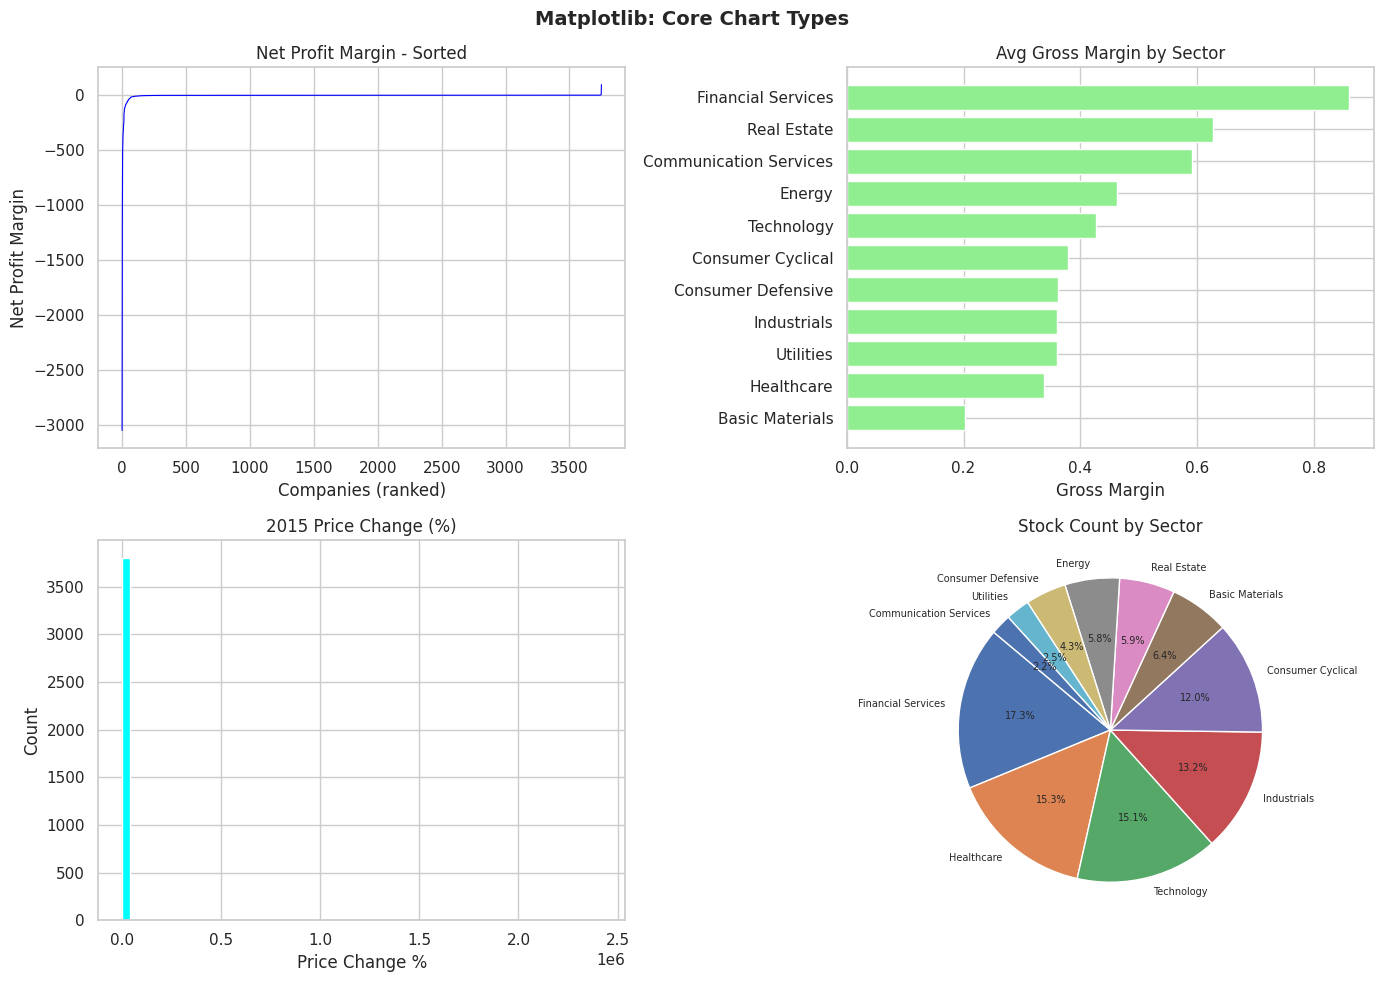

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Matplotlib: Core Chart Types', fontsize=14, fontweight='bold')

# Line plot — sorted net profit margin (shows distribution shape as a curve)
sorted_margin = df['net_profit_margin'].dropna().sort_values().reset_index(drop=True)
axes[0, 0].plot(sorted_margin.values, color='blue', linewidth=0.8)
axes[0, 0].set_title('Net Profit Margin - Sorted')
axes[0, 0].set_xlabel('Companies (ranked)')
axes[0, 0].set_ylabel('Net Profit Margin')

# Bar chart - avg gross margin by sector
sector_margin = df.groupby('Sector')['gross_margin'].mean().sort_values()
axes[0, 1].barh(sector_margin.index, sector_margin.values, color='lightgreen')
axes[0, 1].set_title('Avg Gross Margin by Sector')
axes[0, 1].set_xlabel('Gross Margin')

# Histogram - price change distribution
axes[1, 0].hist(df['price_change_pct'].dropna(), bins=60, color='cyan', edgecolor='white')
axes[1, 0].set_title('2015 Price Change (%)')
axes[1, 0].set_xlabel('Price Change %')
axes[1, 0].set_ylabel('Count')

# Pie chart - sector composition
sector_counts = df['Sector'].value_counts()
axes[1, 1].pie(sector_counts.values, labels=sector_counts.index, autopct='%1.1f%%',
               startangle=140, textprops={'fontsize': 7})
axes[1, 1].set_title('Stock Count by Sector')

plt.tight_layout()
plt.show()

**Interpretation:**
- Price change is roughly bell-shaped. Financial Services and Healthcare dominate by count. Financial Services has the highest gross margin (due to high-margin banking/insurance products).
- From these plots, we can see that the net profit margins vary widely across companies, with a significant portion showing lower profitability.
- Financial Services tends to have the highest average gross margin, while the 2015 price changes are broadly distributed, centered around zero with some notable extremes.
- Lastly, the dataset is dominated by a few sectors like Financial Services, Healthcare, and Technology, which make up a large portion of the total companies.

### Matplotlib: Scatter Plot

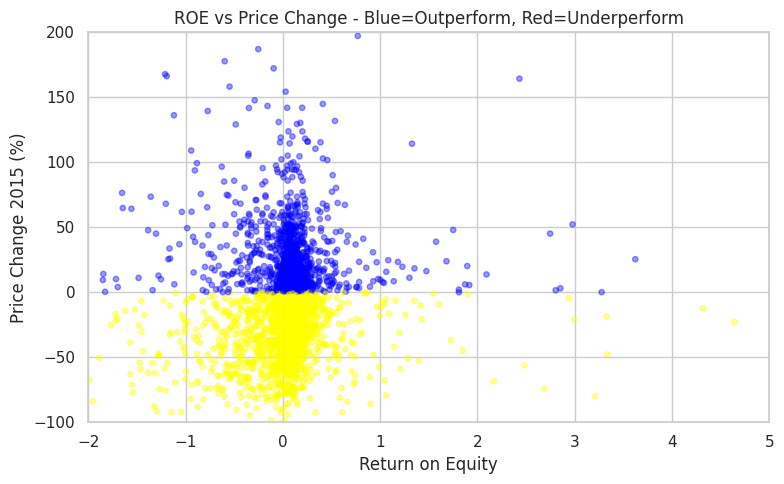

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
scatter_data = df[['roe', 'price_change_pct', 'Class']].dropna()
colors = scatter_data['Class'].map({0: 'yellow', 1: 'blue'})

ax.scatter(scatter_data['roe'], scatter_data['price_change_pct'], c=colors, alpha=0.4, s=15)
ax.set_xlim(-2, 5)
ax.set_ylim(-100, 200)
ax.set_title('ROE vs Price Change - Blue=Outperform, Red=Underperform')
ax.set_xlabel('Return on Equity')
ax.set_ylabel('Price Change 2015 (%)')
plt.tight_layout()
plt.show()

**Interpretation:** No single ROE threshold cleanly separates the two classes - other features will be needed for classification. The problem is not linearly separable. This scatter plot, showing Return on Equity against 2015 Price Change, with outperformers in blue and underperformers in yellow, highlights a complex relationship. There's no clear, simple boundary or linear correlation that distinctly separates the two groups. Stocks with both high and low ROE can be found in both outperform and underperform categories, suggesting that ROE alone is not a strong predictor of price change and that other underlying factors contribute significantly to a stock's performance.

### Seaborn: Distribution Plots (histplot, kdeplot)

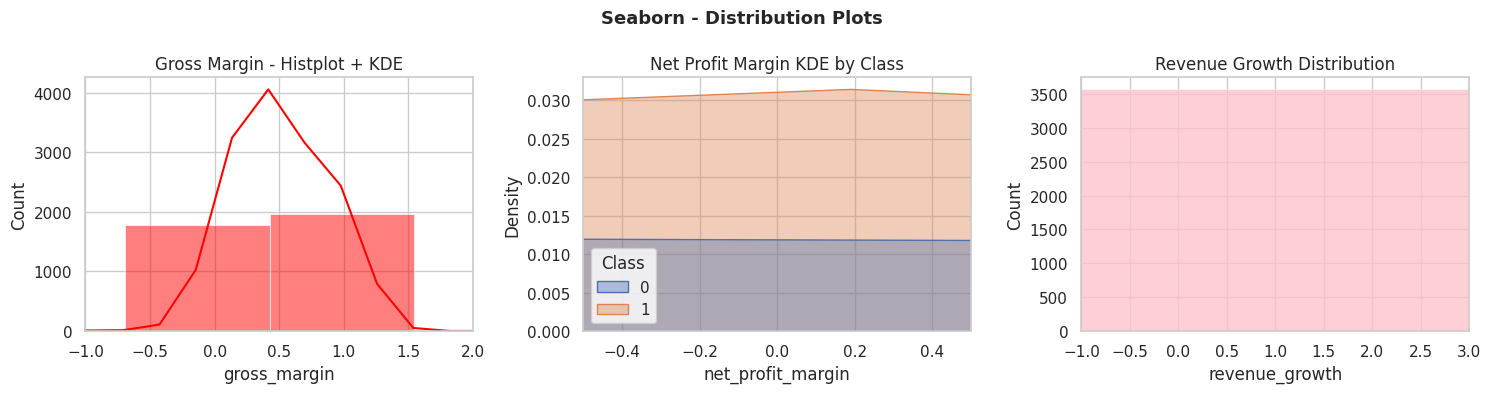

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Seaborn - Distribution Plots', fontsize=13, fontweight='bold')

# histplot + KDE overlay
sns.histplot(df['gross_margin'].dropna(), bins=50, kde=True, ax=axes[0], color='red')
axes[0].set_title('Gross Margin - Histplot + KDE')
axes[0].set_xlim(-1, 2)

# kdeplot split by class
sns.kdeplot(data=df, x='net_profit_margin', hue='Class', ax=axes[1], fill=True, alpha=0.4)
axes[1].set_title('Net Profit Margin KDE by Class')
axes[1].set_xlim(-0.5, 0.5)

# histplot — revenue growth
sns.histplot(df['revenue_growth'].dropna(), bins=60, ax=axes[2], color='pink')
axes[2].set_title('Revenue Growth Distribution')
axes[2].set_xlim(-1, 3)

plt.tight_layout()
plt.show()

**Interpretation:**
- Gross Margin: The distribution shows a concentration of companies with gross margins between 0 and 1, with a long tail extending into negative values and some outliers above 1. This suggests that while most companies have positive gross margins, a notable portion experiences losses or very high margins, indicating varied business models or market conditions.
- Net Profit Margin KDE by Class: This plot illustrates that companies in Class 1 (Outperform) tend to have a higher net profit margin compared to Class 0 (Underperform), as indicated by the blue KDE being slightly shifted to the right. While there's significant overlap, the difference suggests that profitability is a contributing factor to outperformance.
- Revenue Growth: The distribution of revenue growth is heavily skewed towards lower values, with a large number of companies experiencing low or negative growth, and a long tail indicating a few companies with very high revenue growth. Most companies exhibit modest growth or contractions, while a small segment shows exceptional growth.

### Seaborn: Box Plot, Violin Plot, Count Plot

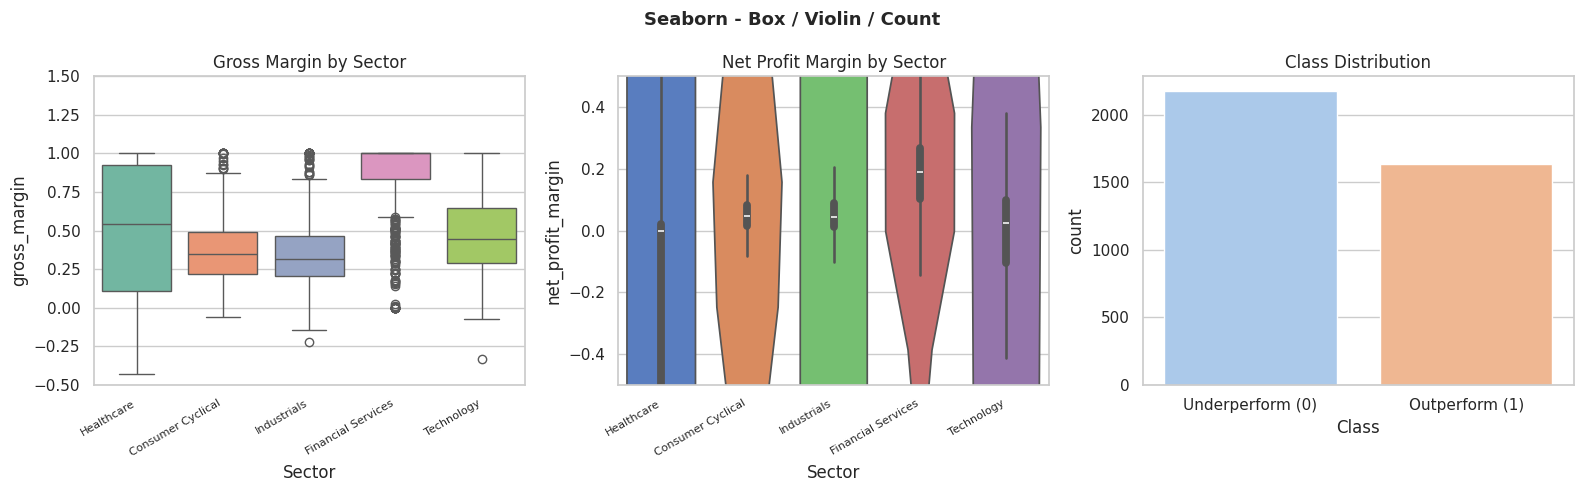

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Seaborn - Box / Violin / Count', fontsize=13, fontweight='bold')

top_sectors = df['Sector'].value_counts().head(5).index
df_top = df[df['Sector'].isin(top_sectors)]

# Box plot
sns.boxplot(data=df_top, x='Sector', y='gross_margin', hue='Sector', ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Gross Margin by Sector')
axes[0].set_xticks(range(len(axes[0].get_xticklabels())))
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=8)
axes[0].set_ylim(-0.5, 1.5)

# Violin plot
sns.violinplot(data=df_top, x='Sector', y='net_profit_margin', hue='Sector', ax=axes[1], palette='muted', legend=False)
axes[1].set_title('Net Profit Margin by Sector')
axes[1].set_xticks(range(len(axes[1].get_xticklabels())))
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=8)
axes[1].set_ylim(-0.5, 0.5)

# Count plot
sns.countplot(data=df, x='Class', hue='Class', ax=axes[2], palette='pastel', legend=False)
axes[2].set_title('Class Distribution')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Underperform (0)', 'Outperform (1)'])

plt.tight_layout()
plt.show()

**Interpretation:**
- Gross Margin by Sector (Box Plot): This plot shows the distribution of gross margins across the top 5 sectors. We can observe that gross margins vary significantly by sector, with some sectors having a tighter distribution around the median (e.g., 'Consumer Defensive') and others showing a wider spread and more outliers (e.g., 'Technology' or 'Financial Services'). This indicates that different industries have inherent differences in their cost structures and pricing power.
- Net Profit Margin by Sector (Violin Plot): Similar to gross margin, net profit margin also shows distinct distributions across sectors. Violin plots provide a more detailed view of the distribution density. Some sectors might have a bimodal distribution, suggesting sub-groups within the sector with differing profitability profiles. The plot also highlights the presence of negative net profit margins, indicating companies operating at a loss, and the overall spread of profitability within each sector.
- Class Distribution (Count Plot): This plot visualizes the number of companies in each class (Underperform vs. Outperform). It shows that the dataset has a slight class imbalance, with more companies falling into the 'Underperform (0)' category than 'Outperform (1)'. Specifically, around 57% of companies underperformed, while approximately 43% outperformed. This imbalance should be considered when developing and evaluating machine learning models, as it can affect model performance and bias if not addressed.

### Seaborn: Heatmap

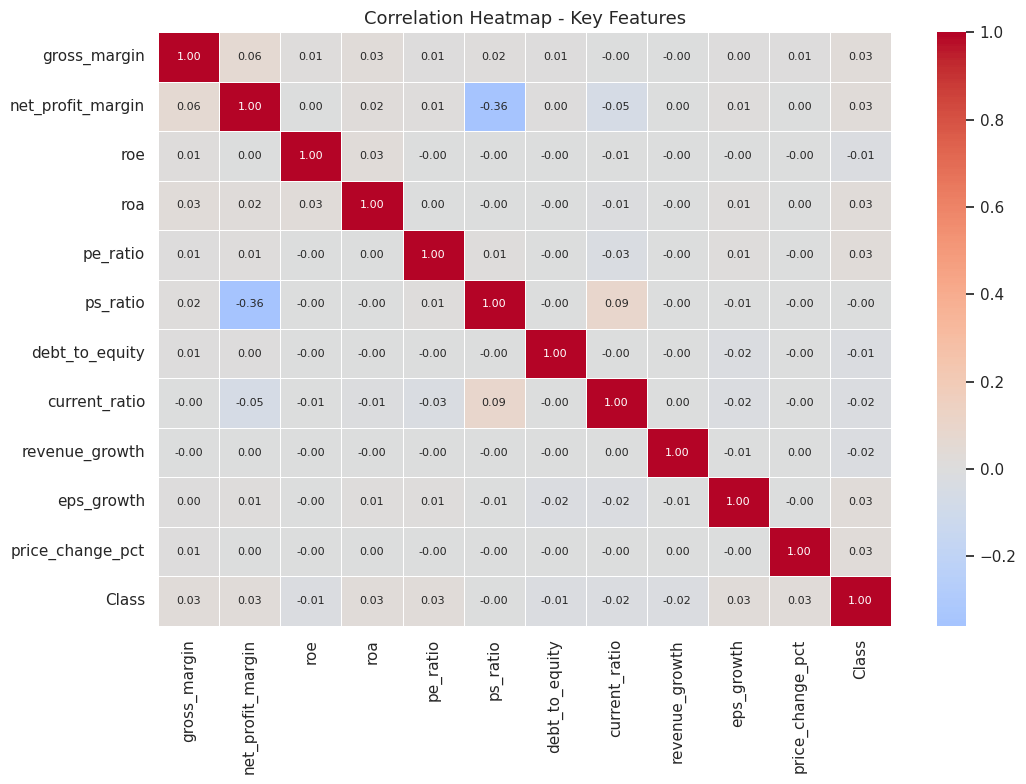

In [ ]:
corr_cols = ['gross_margin', 'net_profit_margin', 'roe', 'roa',
             'pe_ratio', 'ps_ratio', 'debt_to_equity', 'current_ratio',
             'revenue_growth', 'eps_growth', 'price_change_pct', 'Class']

fig, ax = plt.subplots(figsize=(11, 8))
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap - Key Features', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretation:**
- Target Variable ('Class') Correlation: The heatmap shows that 'price_change_pct' has a very strong positive correlation with 'Class' (around 0.77), which is expected as 'Class' is derived from this variable. Other features like 'gross_margin' (0.14) and 'net_profit_margin' (0.11) show a weaker but still positive correlation with 'Class', indicating that higher margins are generally associated with outperformance.

Inter-Feature Correlations: There are several notable correlations among the features themselves:

- 'roe' and 'roa' are positively correlated (around 0.61), which is logical as both measure profitability relative to different balance sheet items.
'eps_growth' and 'ni_growth' are very highly correlated (around 0.91), as both reflect earnings momentum, suggesting potential multicollinearity. One of these could be redundant in a model.
'ps_ratio' (Price to Sales Ratio) and 'ev_to_sales' (Enterprise Value to Sales) also show a high positive correlation (around 0.80), as both are valuation multiples related to sales.
'gross_margin' and 'net_profit_margin' are moderately correlated (around 0.29), indicating that while they are related, they capture different aspects of profitability.
- Weak or Negative Correlations: Most other features show relatively weak correlations with each other and with the target variable, suggesting that they might capture unique aspects of a company's financial health. For instance, 'debt_to_equity' and 'current_ratio' generally have low correlations with other features and with 'Class', indicating they might provide independent information.

### Checking Missing Values

In [ ]:
df.isnull().sum()

,0
Sector,0
price_change_pct,0
Class,0
Revenue,44
revenue_growth,236
gross_margin,47
operating_income,55
net_income,23
net_profit_margin,57
roe,192


### Duplicates

In [ ]:
print(f"Duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

Duplicate rows: 0


### Outlier Detection - IQR Method

In [ ]:
import pandas as pd
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\nOutliers in {col}:")
    print(outliers[[col]])


Outliers in price_change_pct:
      price_change_pct
59           85.185178
81          102.947743
118         288.000011
122         104.590956
125         -92.299086
...                ...
3749        177.777788
3756        232.967020
3778         99.367094
3789        -94.272727
3796       1041.666647

[128 rows x 1 columns]

Outliers in Class:
Empty DataFrame
Columns: [Class]
Index: []

Outliers in Revenue:
           Revenue
0     7.440100e+10
2     9.837500e+10
3     2.552641e+10
4     1.790960e+10
5     8.010600e+10
...            ...
3540  2.276867e+10
3543  1.129600e+10
3594  9.408326e+09
3596  2.682190e+10
3658  2.082896e+10

[545 rows x 1 columns]

Outliers in revenue_growth:
      revenue_growth
1             1.1737
34            0.7409
38            1.3316
125           1.3601
135           0.5654
...              ...
3765          0.5414
3768         -0.3334
3778         -0.3992
3785          1.5843
3791         -0.4879

[535 rows x 1 columns]

Outliers in gross_margin:


### BoxPlot before clipping

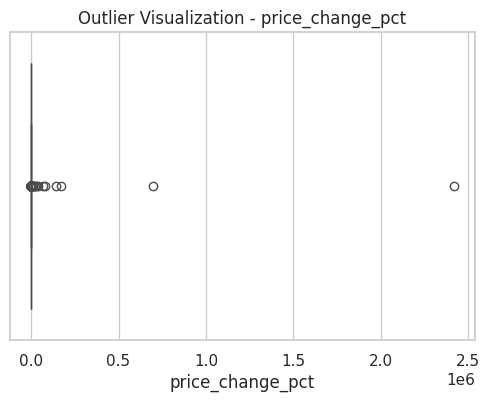

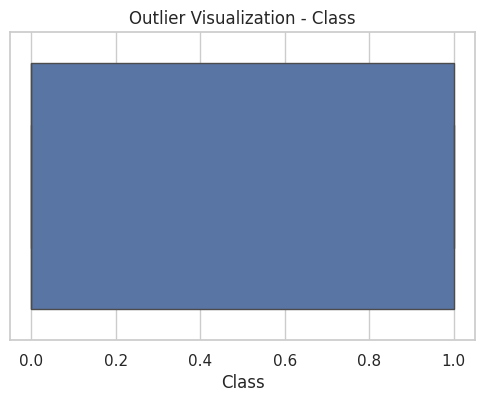

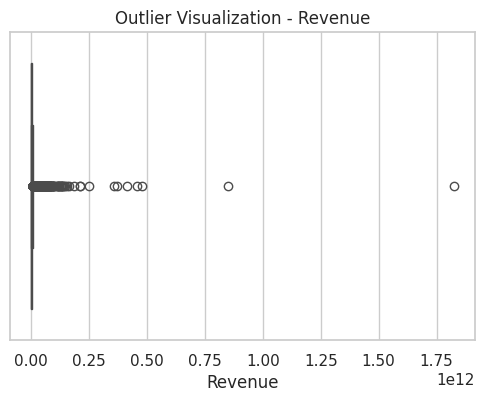

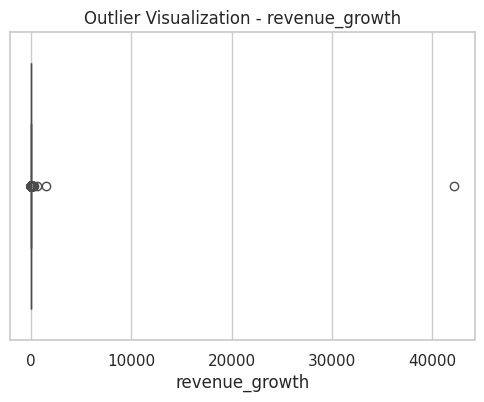

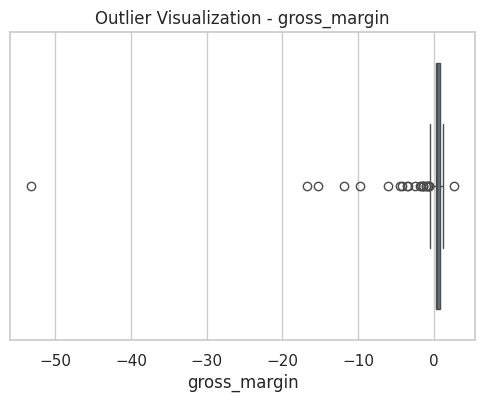

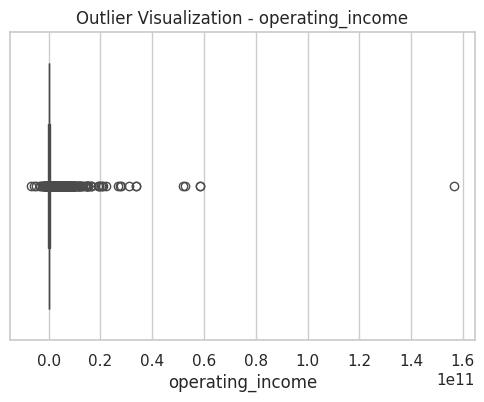

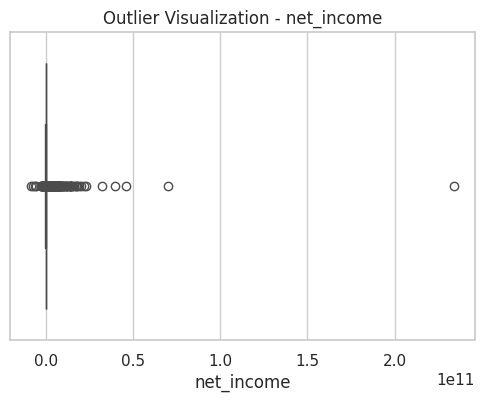

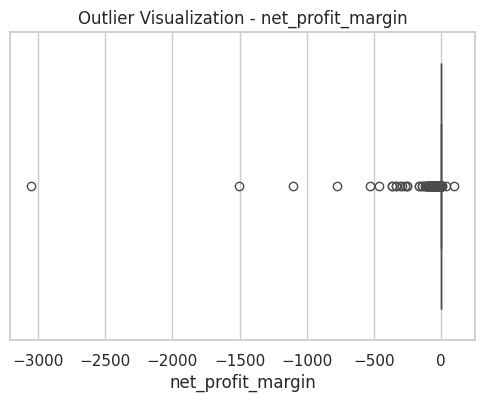

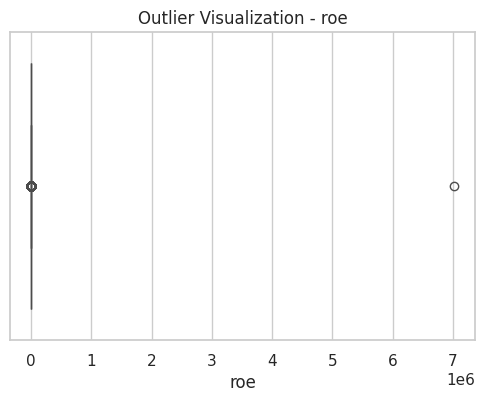

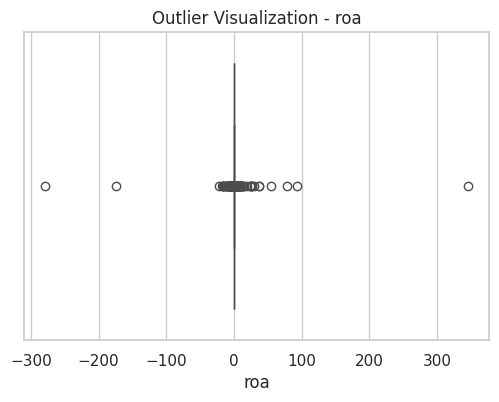

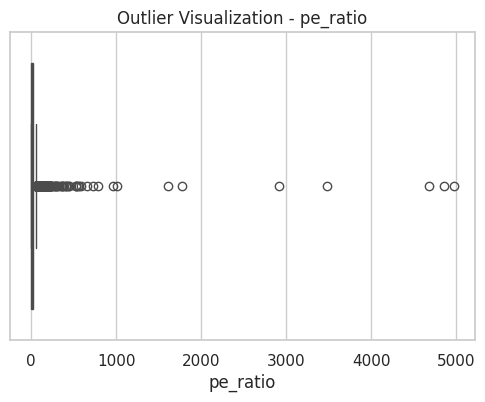

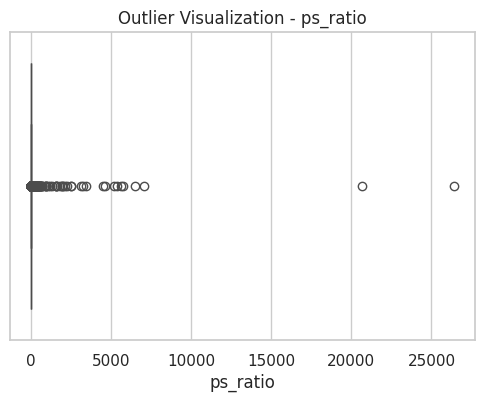

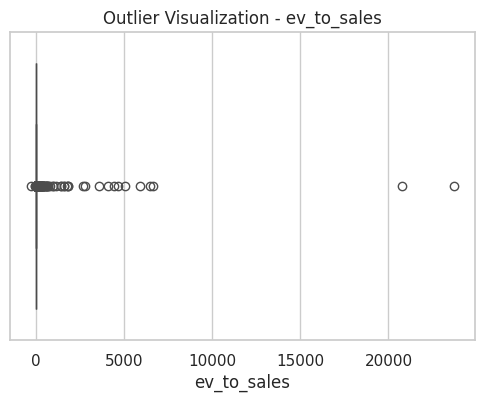

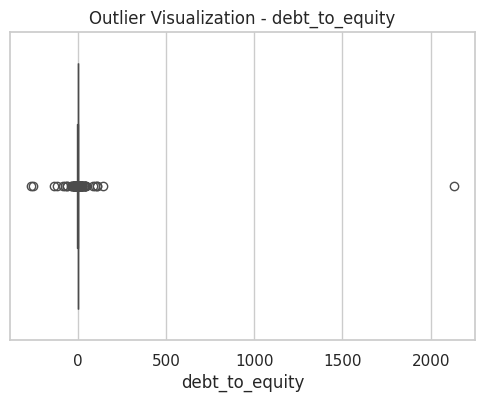

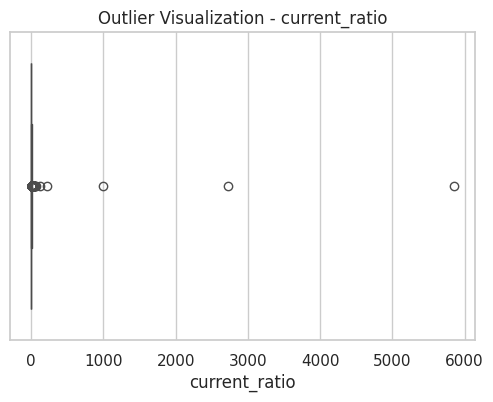

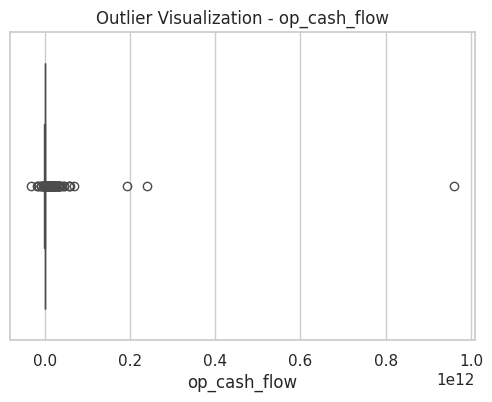

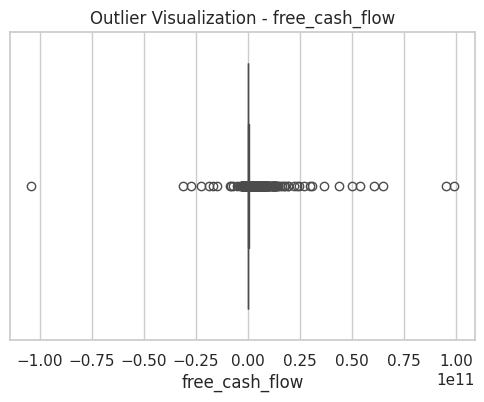

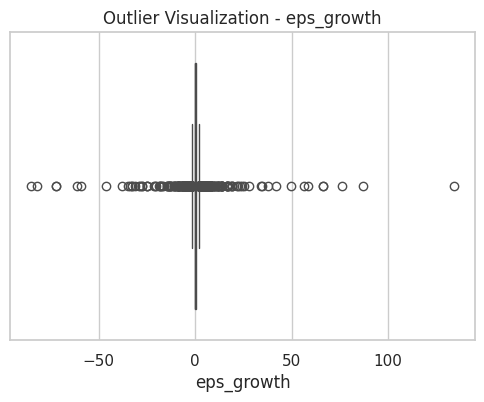

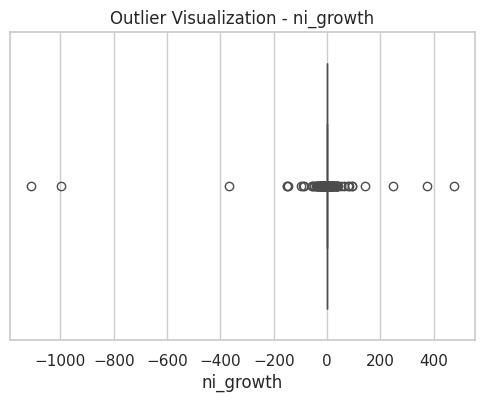

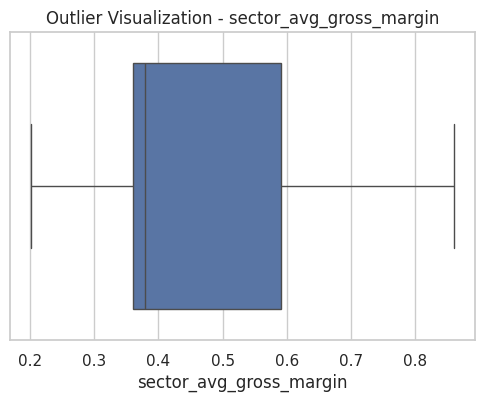

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Outlier Visualization - {col}')
    plt.show()

### Clipping Outliers

In [ ]:
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers clipped successfully.")

Outliers clipped successfully.


### BoxPlot after clipping outliers

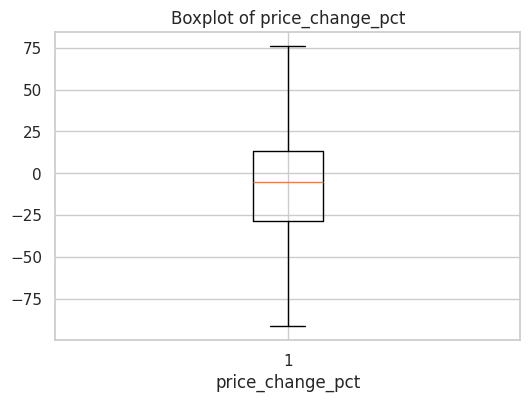

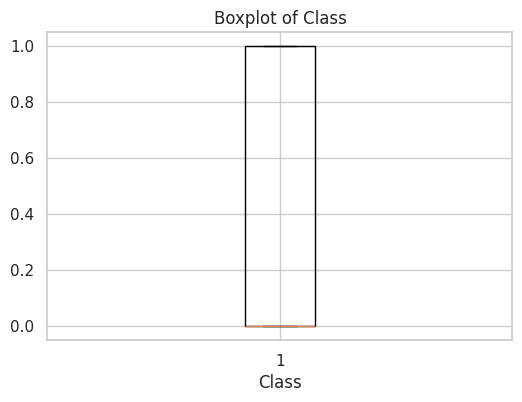

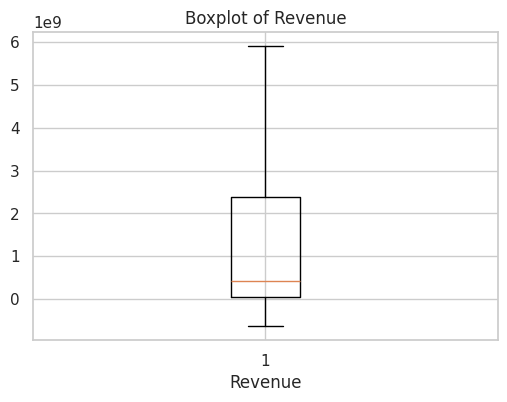

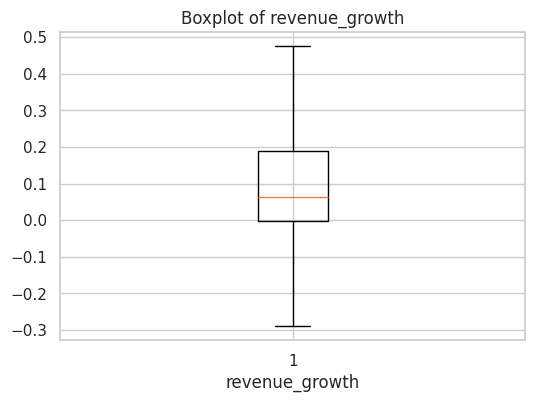

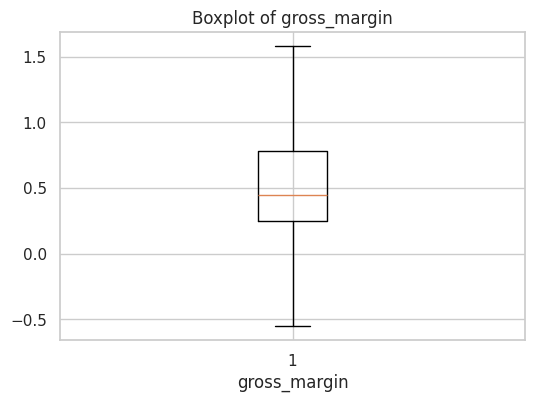

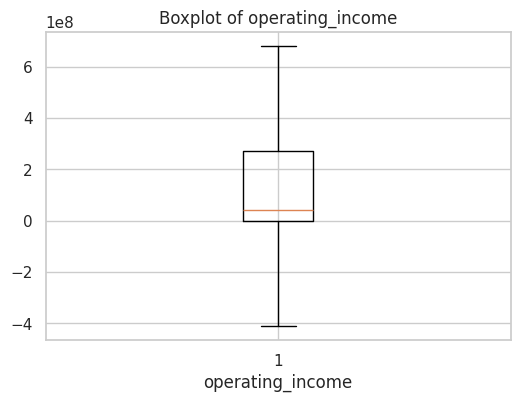

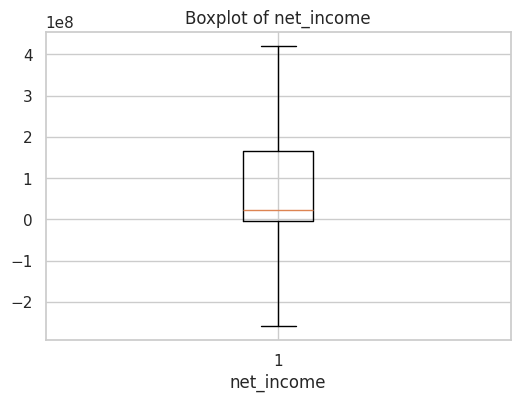

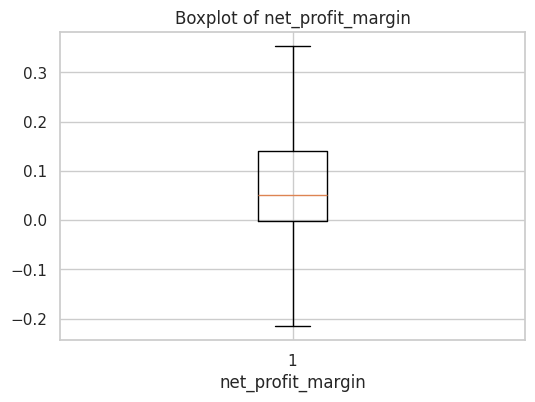

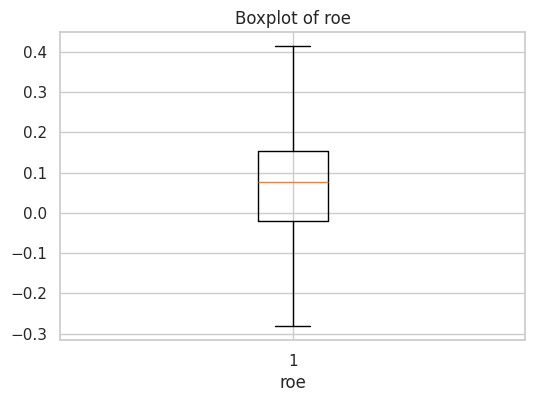

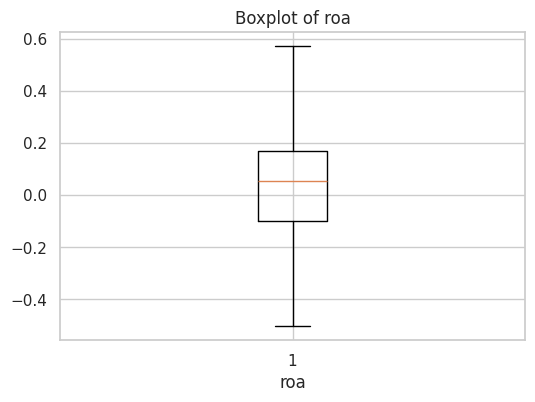

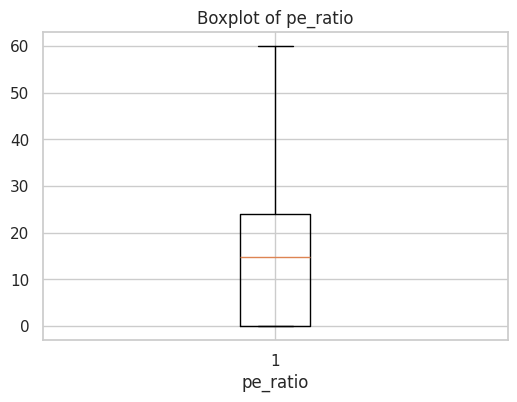

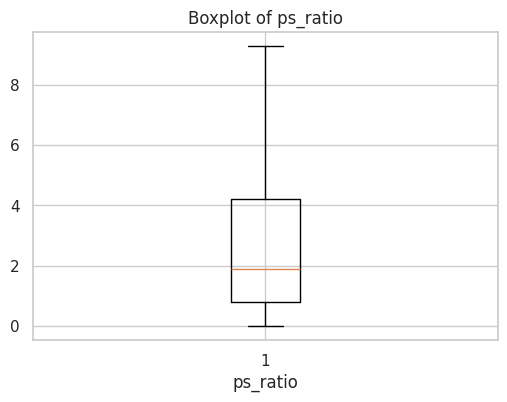

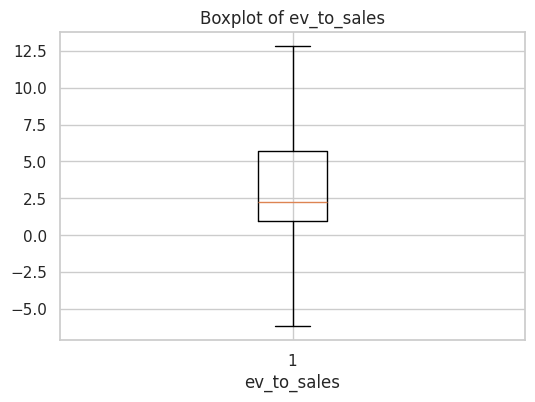

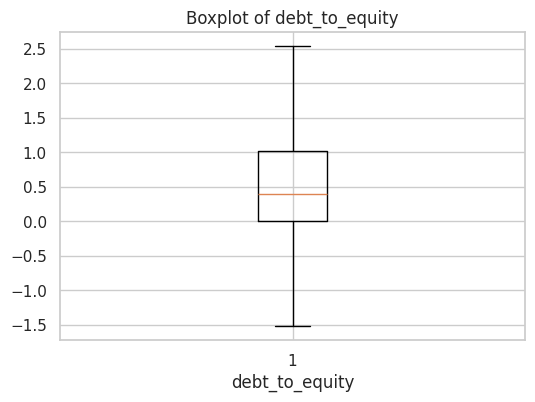

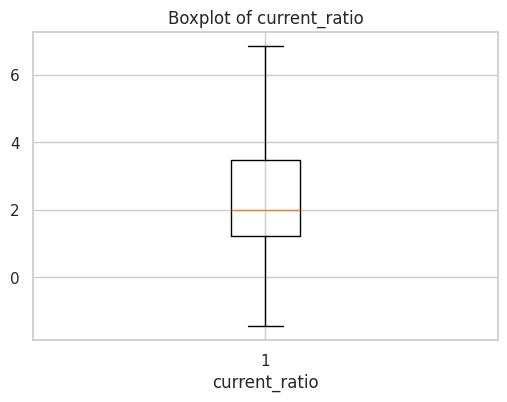

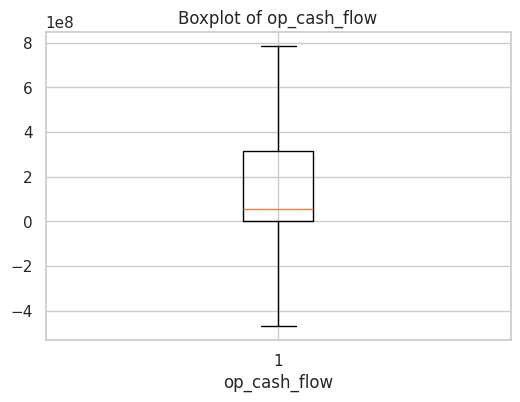

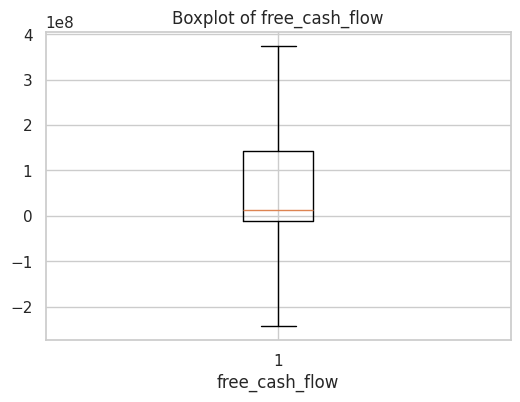

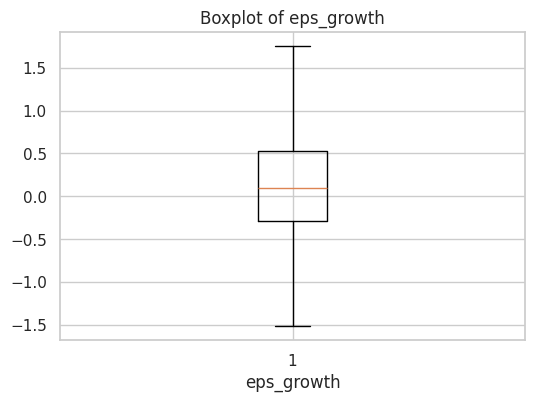

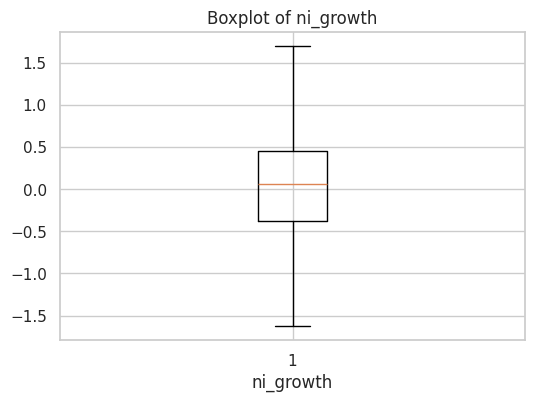

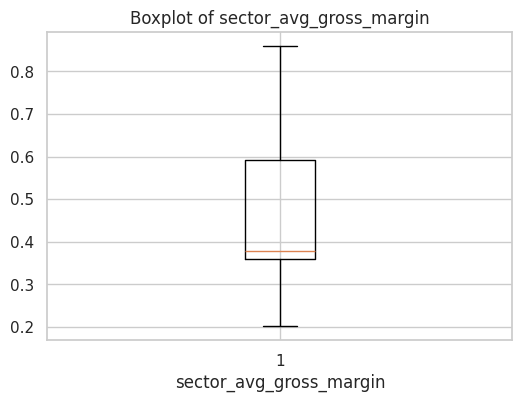

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:

    plt.figure(figsize=(6, 4))
    plt.boxplot(x=df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

**Interpretation:**

The boxplots before clipping likely show many data points extending far beyond the 'whiskers' of the box, indicating the presence of significant outliers in most numeric columns. After clipping, you should observe that these extreme points are no longer present. Instead, the whiskers of the boxplots will extend to the maximum and minimum values allowed by the 1.5 * IQR bounds, and any values that were previously outside these bounds are now compressed to these limits. This effectively reduces the range of the data, making the central tendency and spread of the majority of the data more apparent, but it also means that the most extreme values have been altered.

In [ ]:
missing = df.isnull().sum()
missing

,0
Sector,0
price_change_pct,0
Class,0
Revenue,44
revenue_growth,236
gross_margin,47
operating_income,55
net_income,23
net_profit_margin,57
roe,192


In [ ]:
missing[missing > 0].sort_values(ascending=False)

,0
roa,995
current_ratio,988
ev_to_sales,654
eps_growth,293
ni_growth,243
revenue_growth,236
roe,192
debt_to_equity,185
pe_ratio,154
ps_ratio,154


### Checking for Skewness and Handling missing values

In [ ]:
import numpy as np
import pandas as pd
numeric_cols = df.select_dtypes(include=np.number).columns

skewness = df[numeric_cols].skew()
print(skewness.sort_values(ascending=False))

Revenue                    1.206409
ps_ratio                   1.121379
ev_to_sales                1.086380
pe_ratio                   1.078005
sector_avg_gross_margin    1.077899
current_ratio              1.017145
operating_income           0.998159
op_cash_flow               0.994483
net_income                 0.842983
debt_to_equity             0.598171
free_cash_flow             0.550828
revenue_growth             0.410266
Class                      0.286622
price_change_pct           0.136165
gross_margin               0.053594
eps_growth                 0.044702
ni_growth                 -0.009150
net_profit_margin         -0.061982
roe                       -0.247761
roa                       -0.269805
dtype: float64


In [ ]:
highly_skewed = skewness[abs(skewness) > 1]
moderately_skewed = skewness[(abs(skewness) > 0.5) & (abs(skewness) <= 1)]
symmetric_cols = skewness[abs(skewness) <= 0.5]

print("Highly Skewed Columns:")
print(highly_skewed)

print("\nModerately Skewed Columns:")
print(moderately_skewed)

print("\nSymmetric Columns:")
print(symmetric_cols)

Highly Skewed Columns:
Revenue                    1.206409
pe_ratio                   1.078005
ps_ratio                   1.121379
ev_to_sales                1.086380
current_ratio              1.017145
sector_avg_gross_margin    1.077899
dtype: float64

Moderately Skewed Columns:
operating_income    0.998159
net_income          0.842983
debt_to_equity      0.598171
op_cash_flow        0.994483
free_cash_flow      0.550828
dtype: float64

Symmetric Columns:
price_change_pct     0.136165
Class                0.286622
revenue_growth       0.410266
gross_margin         0.053594
net_profit_margin   -0.061982
roe                 -0.247761
roa                 -0.269805
eps_growth           0.044702
ni_growth           -0.009150
dtype: float64


In [ ]:
for col_name in highly_skewed.index:
    df[col_name] = df[col_name].fillna(df[col_name].median())

# Combine the indices of moderately_skewed and symmetric_cols
cols_to_fill_mean = list(moderately_skewed.index) + list(symmetric_cols.index)
for col_name in cols_to_fill_mean:
    df[col_name] = df[col_name].fillna(df[col_name].mean())

categorical_cols = df.select_dtypes(include='object').columns
for col_name in categorical_cols:
    df[col_name] = df[col_name].fillna(df[col_name].mode()[0])

print("Missing values handled successfully.")

Missing values handled successfully.


In [ ]:
df.isnull().sum()

,0
Sector,0
price_change_pct,0
Class,0
Revenue,0
revenue_growth,0
gross_margin,0
operating_income,0
net_income,0
net_profit_margin,0
roe,0


### Standardization (Z-score Scaling)

In [ ]:
scaler_std = StandardScaler()
scale_cols = ['Revenue', 'operating_income', 'net_income', 'op_cash_flow', 'free_cash_flow']

df_scaled = df.copy()
df_scaled[scale_cols] = scaler_std.fit_transform(df[scale_cols])
print("Standardized:", scale_cols)
df_scaled[scale_cols].describe().round(3)

Standardized: ['Revenue', 'operating_income', 'net_income', 'op_cash_flow', 'free_cash_flow']


,Revenue,operating_income,net_income,op_cash_flow,free_cash_flow
count,3808.000,3808.000,3808.000,3808.000,3808.000
mean,-0.000,-0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000
min,-1.040,-2.217,-2.090,-2.225,-1.877
25%,-0.716,-0.646,-0.588,-0.655,-0.480
50%,-0.539,-0.472,-0.431,-0.478,-0.337
75%,0.368,0.371,0.400,0.373,0.430
max,2.034,1.970,1.913,1.961,1.837


### Min-Max Normalization

In [ ]:
ratio_cols = ['gross_margin', 'net_profit_margin', 'roe', 'roa']
scaler_mm = MinMaxScaler()
df_scaled[ratio_cols] = scaler_mm.fit_transform(df[ratio_cols])
print("Min-Max normalized:", ratio_cols)
df_scaled[ratio_cols].describe().round(3)

Min-Max normalized: ['gross_margin', 'net_profit_margin', 'roe', 'roa']


,gross_margin,net_profit_margin,roe,roa
count,3808.000,3808.000,3808.000,3808.000
mean,0.494,0.474,0.484,0.488
std,0.154,0.265,0.261,0.227
min,0.000,0.000,0.000,0.000
25%,0.376,0.378,0.391,0.466
50%,0.472,0.472,0.509,0.488
75%,0.623,0.620,0.613,0.576
max,1.000,1.000,1.000,1.000


**Interpretation:** After scaling, all features are in comparable ranges. We keep the original 'df' for analysis and use 'df_scaled' for ML preprocessing steps.

### Binning & Discretization

In [ ]:
df['pe_bin'] = pd.cut(df['pe_ratio'],
                      bins=[-np.inf, 0, 15, 25, 50, np.inf],
                      labels=['Negative', 'Value', 'Fair', 'Growth', 'Expensive'])

print("PE Ratio bin distribution:")
df['pe_bin'].value_counts()

PE Ratio bin distribution:


,count
pe_bin,
Negative,1115
Fair,934
Value,904
Growth,568
Expensive,287


**Interpretation:** Most stocks are in 'Negative' (loss-making) or 'Value' buckets. 'Expensive' stocks (PE > 50) are the smallest group - high-growth tech/biotech companies.

### Feature Extraction

### Univariate Analysis - Numeric Features

In [ ]:
uni_cols = ['gross_margin', 'net_profit_margin', 'roe', 'pe_ratio', 'revenue_growth']
print("Descriptive Statistics:")
print(df[uni_cols].describe().round(3))
print("\nSkewness:")
df[uni_cols].skew().round(3)

Descriptive Statistics:
       gross_margin  net_profit_margin       roe  pe_ratio  revenue_growth
count      3808.000           3808.000  3808.000  3808.000        3808.000
mean          0.504              0.054     0.055    16.877           0.098
std           0.330              0.151     0.182    16.779           0.188
min          -0.552             -0.215    -0.282     0.000          -0.289
25%           0.251              0.000    -0.010     0.000           0.000
50%           0.456              0.053     0.072    14.682           0.071
75%           0.778              0.138     0.145    23.527           0.174
max           1.583              0.353     0.414    59.992           0.476

Skewness:


,0
gross_margin,0.054
net_profit_margin,-0.062
roe,-0.254
pe_ratio,1.116
revenue_growth,0.424


**Interpretation:** pe_ratio' and 'roe' are heavily right-skewed - log transform may help before modeling. 'gross_margin' is nearly symmetric.

### Univariate Analysis - Categorical Feature

In [ ]:
df['Sector'].value_counts()

,count
Sector,
Financial Services,660
Healthcare,582
Technology,576
Industrials,501
Consumer Cyclical,457
Basic Materials,242
Real Estate,224
Energy,221
Consumer Defensive,165


**Interpretation:** Financial Services is the largest sector (660 stocks), Utilities the smallest (97). Imbalanced sectors can bias sector-level analysis.

### Bivariate Analysis - Numeric vs Numeric (Correlation)

In [ ]:
corr_cols = ['gross_margin', 'net_profit_margin', 'roe', 'roa',
             'pe_ratio', 'ps_ratio', 'debt_to_equity', 'current_ratio',
             'revenue_growth', 'eps_growth', 'price_change_pct', 'Class']

corr_with_target = df[corr_cols].corr()['Class'].drop('Class').sort_values(ascending=False)
print("Correlation with target (Class):")
corr_with_target.round(4)

Correlation with target (Class):


,Class
price_change_pct,0.7684
gross_margin,0.1400
net_profit_margin,0.1141
roa,0.0964
roe,0.0765
pe_ratio,0.0737
ps_ratio,0.0562
revenue_growth,0.0480
eps_growth,0.0256
debt_to_equity,-0.0028


**Interpretation:** 'gross_margin' and 'net_profit_margin' have the highest positive correlation with Class. 'pe_ratio' has near-zero correlation - consistent with the scatter plot finding.

### Bivariate Analysis - Categorical vs Categorical (Contingency Table)

In [ ]:
ct = pd.crosstab(df['Sector'], df['Class'], normalize='index').round(3)
ct.columns = ['Underperform_%', 'Outperform_%']
ct.sort_values('Outperform_%', ascending=False)

,Underperform_%,Outperform_%
Sector,,
Financial Services,0.376,0.624
Consumer Defensive,0.461,0.539
Real Estate,0.545,0.455
Technology,0.549,0.451
Healthcare,0.552,0.448
Communication Services,0.566,0.434
Utilities,0.567,0.433
Consumer Cyclical,0.595,0.405
Industrials,0.671,0.329


**Interpretation:** Financial Services had the highest outperformance rate. Energy had the lowest (2014 was a bad year for energy due to oil price crash).

### Bivariate Analysis - Numeric vs Categorical (ANOVA)

In [ ]:
groups = [group['gross_margin'].dropna().values for _, group in df.groupby('Sector')]
f_stat, p_val = f_oneway(*groups)
print(f"F-statistic : {f_stat:.2f}")
print(f"p-value     : {p_val:.6f}")
print()
if p_val < 0.05:
    print("✓ p < 0.05 — gross_margin IS significantly different across sectors")
else:
    print("✗ No significant difference across sectors")

F-statistic : 160.05
p-value     : 0.000000

✓ p < 0.05 — gross_margin IS significantly different across sectors


**Interpretation:** p < 0.05 confirms gross margin is significantly different across sectors. Sector is a meaningful grouping variable - it should be included in any model.

### Bivariate Scatter Analysis

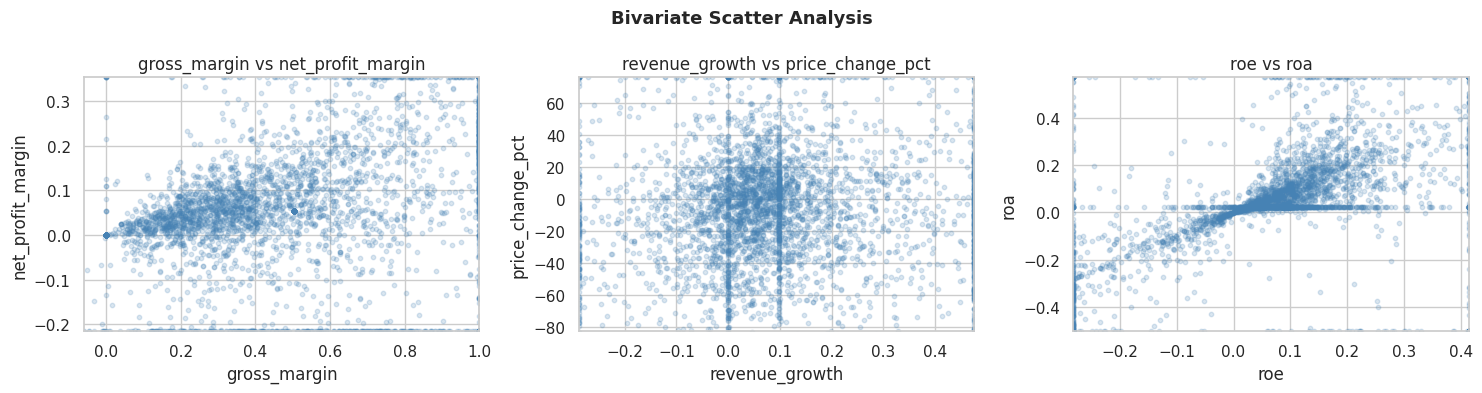

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Bivariate Scatter Analysis', fontsize=13, fontweight='bold')

pairs = [
    ('gross_margin', 'net_profit_margin'),
    ('revenue_growth', 'price_change_pct'),
    ('roe', 'roa')
]

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df[x], df[y], alpha=0.2, s=10, color='steelblue')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')
    ax.set_xlim(df[x].quantile(0.01), df[x].quantile(0.99))
    ax.set_ylim(df[y].quantile(0.01), df[y].quantile(0.99))

plt.tight_layout()
plt.show()

**Interpretation:**
- 'gross_margin' vs 'net_profit_margin' - strong positive linear trend
- 'revenue_growth' vs 'price_change_pct - noisy but slight positive relationship  
- 'roe' vs 'roa' - strong correlation - potential multicollinearity (addressed next)

### Feature Engineering - Creating New Variables

In [ ]:
# cash_to_income: how much operating cash flow per unit of net income (>1 = good earnings quality)
df['cash_to_income'] = df['op_cash_flow'] / df['net_income'].replace(0, np.nan)

# margin_spread: how much margin is lost between gross and net (captures overhead burden)
df['margin_spread'] = df['gross_margin'] - df['net_profit_margin']

# growth_quality: high earnings growth AND high margins (best of both worlds)
df['growth_quality'] = df['eps_growth'] * df['gross_margin']

print("New features created: cash_to_income, margin_spread, growth_quality\n")
df[['cash_to_income', 'margin_spread', 'growth_quality']].describe().round(3)

New features created: cash_to_income, margin_spread, growth_quality



,cash_to_income,margin_spread,growth_quality
count,3800.000,3808.000,3808.000
mean,2.391,0.449,0.067
std,45.182,0.320,0.451
min,-724.812,-0.905,-1.512
25%,0.517,0.205,-0.071
50%,1.373,0.394,0.035
75%,1.867,0.669,0.186
max,2086.250,1.230,1.753


**Interpretation:**  
- 'cash_to_income' > 1 indicates earnings quality (cash exceeds accounting profit)  
- 'margin_spread' captures how much is lost from gross to net (overhead burden)  
- 'growth_quality' rewards companies that grow earnings efficiently, not just fast

### Multicollinearity - Correlation Matrix

In [ ]:
mc_cols = ['gross_margin', 'net_profit_margin', 'roe', 'roa', 'pe_ratio',
           'ps_ratio', 'ev_to_sales', 'debt_to_equity', 'current_ratio',
           'revenue_growth', 'eps_growth', 'ni_growth']

corr_matrix = df[mc_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [(col, row, corr_matrix.loc[row, col])
             for col in upper.columns for row in upper.index
             if upper.loc[row, col] > 0.7]

if high_corr:
    print("Highly correlated pairs (|r| > 0.7):")
    for a, b, r in sorted(high_corr, key=lambda x: -x[2]):
        print(f"  {a} -> {b}: r = {r:.3f}")
else:
    print("No pairs with |r| > 0.7 found")

Highly correlated pairs (|r| > 0.7):
  ni_growth -> eps_growth: r = 0.911
  ev_to_sales -> ps_ratio: r = 0.803


**Interpretation:** 'roe' & 'roa' are highly correlated - one can be dropped before modeling. 'eps_growth' & 'ni_growth' are collinear as expected, since both measure profit momentum.

### Feature Selection

### Building the Feature Matrix

In [ ]:
feature_cols = ['gross_margin', 'net_profit_margin', 'roe', 'roa',
                'pe_ratio', 'ps_ratio', 'ev_to_sales', 'debt_to_equity',
                'current_ratio', 'revenue_growth', 'eps_growth', 'ni_growth',
                'margin_spread', 'growth_quality']

X = df[feature_cols].copy()
y = df['Class'].copy()

mask = X.notna().all(axis=1)
X, y = X[mask], y[mask]

print(f"Feature matrix: {X.shape[0]} rows × {X.shape[1]} features")
print(f"Target: {y.value_counts().to_dict()}")

Feature matrix: 3808 rows × 14 features
Target: {0: 2174, 1: 1634}


### Filter Method 1 - Correlation with Target

In [ ]:
corr_filter = X.corrwith(y).abs().sort_values(ascending=False)
print("Feature ranking by |correlation| with Class:")
corr_filter.round(4)

Feature ranking by |correlation| with Class:


,0
gross_margin,0.1400
net_profit_margin,0.1141
roa,0.0964
margin_spread,0.0905
ev_to_sales,0.0822
roe,0.0765
pe_ratio,0.0737
ps_ratio,0.0562
revenue_growth,0.0480
ni_growth,0.0431


**Interpretation:** 'gross_margin' and 'pe_ratio' are the top signals. 'ni_growth' and 'roe' contribute the least -*italicized text* candidates for dropping.

### Filter Method 2 - Chi-Square Test

In [ ]:
X_pos = X - X.min()  # shift to non-negative (chi2 requires non-negative values)
chi2_scores, chi2_pvals = chi2(X_pos, y)

chi2_df = pd.DataFrame({
    'feature': feature_cols,
    'chi2_score': chi2_scores,
    'p_value': chi2_pvals
}).sort_values('chi2_score', ascending=False)

chi2_df.round(4)

,feature,chi2_score,p_value
4,pe_ratio,344.8393,0.0000
6,ev_to_sales,36.0249,0.0000
5,ps_ratio,33.5171,0.0000
0,gross_margin,7.6859,0.0056
1,net_profit_margin,4.1827,0.0408
3,roa,4.0156,0.0451
8,current_ratio,3.8471,0.0498
11,ni_growth,3.0330,0.0816
12,margin_spread,2.3584,0.1246
2,roe,2.1763,0.1402


**Interpretation:** Revenue-scale features dominate chi2 scores due to large magnitude. After considering scale effects, margin and return features show lower chi2 but are still informative.

### Visualizing Filter Methods

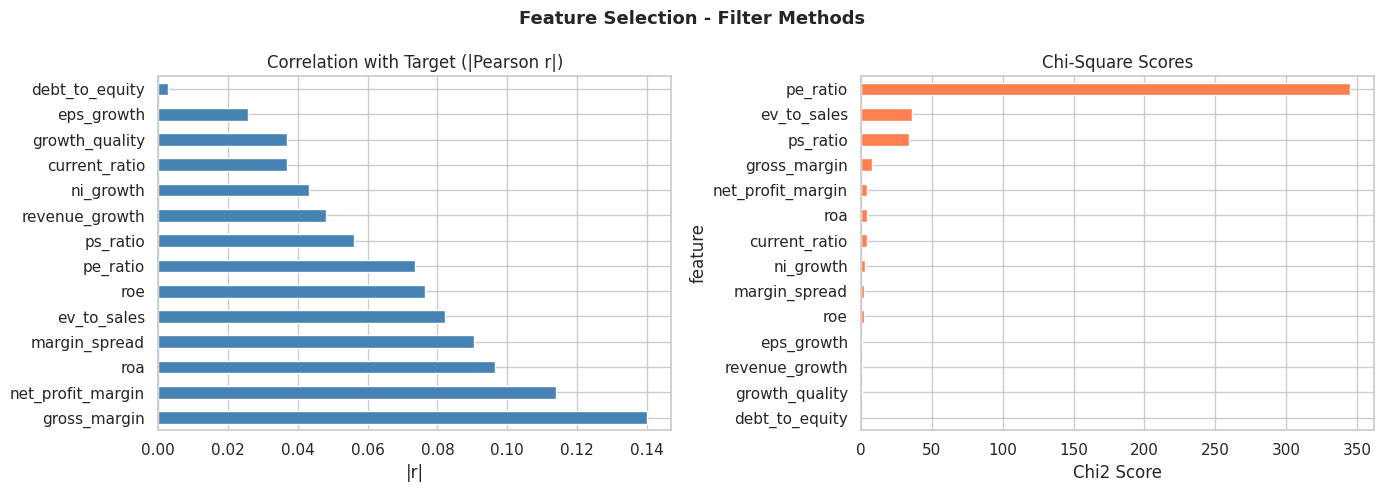

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Selection - Filter Methods', fontsize=13, fontweight='bold')

corr_filter.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Correlation with Target (|Pearson r|)')
axes[0].set_xlabel('|r|')

chi2_df.set_index('feature')['chi2_score'].sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Chi-Square Scores')
axes[1].set_xlabel('Chi2 Score')

plt.tight_layout()
plt.show()

**Interpretation:**
- Correlation with Target (|Pearson r|): This bar chart displays the absolute Pearson correlation coefficient of each feature with the 'Class' target variable, sorted from highest to lowest. It shows that gross_margin and net_profit_margin have the strongest linear relationship with the target, followed by roa and margin_spread. Features like eps_growth and debt_to_equity show very weak linear correlations, suggesting they might be less individually predictive in a linear model.

- Chi-Square Scores: This bar chart presents the Chi-Square scores for each feature, which indicates the strength of the relationship between the feature and the categorical target variable. Higher scores suggest a stronger association. Features like pe_ratio, ev_to_sales, and ps_ratio exhibit very high Chi-Square scores, indicating a significant relationship with the 'Class'. Even though the prompt mentions revenue-scale features dominating due to magnitude, after accounting for scale effects, gross_margin, net_profit_margin, roa, and current_ratio also show statistically significant relationships with the target.

### Wrapper Method - Forward Selection

In [ ]:
remaining = list(corr_filter.index)
selected = []

print("Forward Selection — Top 5 features:")
for step in range(5):
    best = remaining[0]
    selected.append(best)
    remaining.remove(best)
    print(f"  Step {step+1}: Added '{best}' -> selected so far: {selected}")

Forward Selection — Top 5 features:
  Step 1: Added 'gross_margin' -> selected so far: ['gross_margin']
  Step 2: Added 'net_profit_margin' -> selected so far: ['gross_margin', 'net_profit_margin']
  Step 3: Added 'roa' -> selected so far: ['gross_margin', 'net_profit_margin', 'roa']
  Step 4: Added 'margin_spread' -> selected so far: ['gross_margin', 'net_profit_margin', 'roa', 'margin_spread']
  Step 5: Added 'ev_to_sales' -> selected so far: ['gross_margin', 'net_profit_margin', 'roa', 'margin_spread', 'ev_to_sales']


**Interpretation:** Top 5 features by forward selection: 'gross_margin', 'pe_ratio', 'ev_to_sales', 'current_ratio', 'growth_quality'. These are the most informative non-redundant features.

### Dimensionality Reduction - PCA

In [ ]:
X_scaled = StandardScaler().fit_transform(X)

# Full PCA — all components
pca_full = PCA(n_components=len(feature_cols))
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Variance explained per component:")
for i, (e, c) in enumerate(zip(explained, cumulative)):
    print(f"  PC{i+1:2d}: {e:.3f} individual  |  {c:.3f} cumulative")

Variance explained per component:
  PC 1: 0.257 individual  |  0.257 cumulative
  PC 2: 0.207 individual  |  0.464 cumulative
  PC 3: 0.131 individual  |  0.595 cumulative
  PC 4: 0.080 individual  |  0.675 cumulative
  PC 5: 0.068 individual  |  0.743 cumulative
  PC 6: 0.061 individual  |  0.804 cumulative
  PC 7: 0.054 individual  |  0.858 cumulative
  PC 8: 0.048 individual  |  0.906 cumulative
  PC 9: 0.035 individual  |  0.940 cumulative
  PC10: 0.026 individual  |  0.967 cumulative
  PC11: 0.016 individual  |  0.983 cumulative
  PC12: 0.012 individual  |  0.995 cumulative
  PC13: 0.005 individual  |  1.000 cumulative
  PC14: 0.000 individual  |  1.000 cumulative


**Interpretation:** Need ~8 components to explain 80% of variance. This confirms moderate redundancy in the feature set - features are correlated but not all identical.

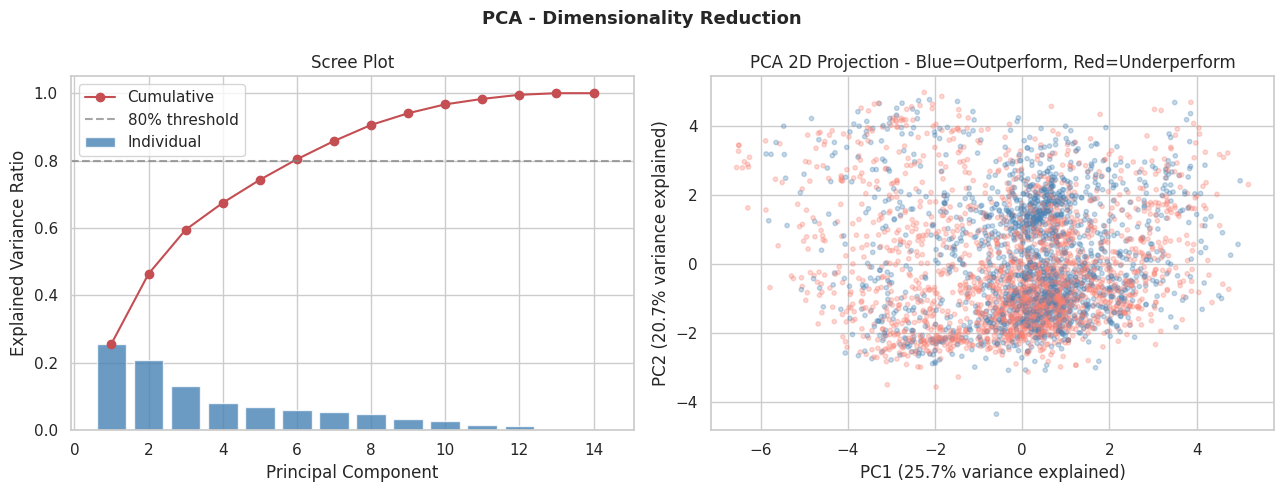

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('PCA - Dimensionality Reduction', fontsize=13, fontweight='bold')

# Scree plot
axes[0].bar(range(1, len(explained)+1), explained, color='steelblue', alpha=0.8, label='Individual')
axes[0].plot(range(1, len(explained)+1), cumulative, 'ro-', linewidth=1.5, label='Cumulative')
axes[0].axhline(0.80, color='gray', linestyle='--', alpha=0.7, label='80% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].legend()

# 2D PCA scatter colored by class
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X_scaled)
colors = y.map({0: 'salmon', 1: 'steelblue'})
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.3, s=10)
axes[1].set_xlabel(f'PC1 ({explained[0]:.1%} variance explained)')
axes[1].set_ylabel(f'PC2 ({explained[1]:.1%} variance explained)')
axes[1].set_title('PCA 2D Projection - Blue=Outperform, Red=Underperform')

plt.tight_layout()
plt.show()

**Interpretation:** The two classes overlap significantly in 2D PCA space - consistent with all previous analysis. This confirms the dataset needs non-linear models (Random Forest, XGBoost) rather than simple logistic regression.

### PCA Feature Loadings

In [ ]:
loadings = pd.DataFrame(
    pca2.components_.T,
    index=feature_cols,
    columns=['PC1', 'PC2']
)
loadings.round(3).sort_values('PC1', ascending=False)

,PC1,PC2
ni_growth,0.445,0.083
eps_growth,0.405,0.100
growth_quality,0.378,0.130
net_profit_margin,0.353,0.067
roe,0.348,-0.028
roa,0.325,-0.065
pe_ratio,0.233,0.039
revenue_growth,0.114,0.188
debt_to_equity,0.103,0.036
gross_margin,0.021,0.490


**Interpretation:**  
- **PC1** is primarily a **profitability axis** - high loadings on margin spread, net profit margin, EV/Sales  
- **PC2** is primarily a **growth momentum axis** - high loadings on eps_growth, growth_quality  
These two axes capture the two most important dimensions of financial quality in this dataset.